In [100]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

pd.set_option('display.max_columns', None)


In [101]:
# =========================================================
# 2. LOAD DATA
# =========================================================

nav = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Data_Analyst_Intern\bluestock_mf_capstone\Data\Raw\02_nav_history.csv")

benchmark = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Data_Analyst_Intern\bluestock_mf_capstone\Data\Raw\10_benchmark_indices.csv")

fund_master = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Data_Analyst_Intern\bluestock_mf_capstone\Data\Raw\01_fund_master.csv")

In [102]:
nav


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
...,...,...,...
45995,149324,2026-05-25,292.4810
45996,149324,2026-05-26,291.2707
45997,149324,2026-05-27,288.8007
45998,149324,2026-05-28,280.6873


In [103]:
benchmark

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
...,...,...,...
8045,2026-05-25,CRISIL_GILT,2278.26
8046,2026-05-26,CRISIL_GILT,2281.42
8047,2026-05-27,CRISIL_GILT,2281.30
8048,2026-05-28,CRISIL_GILT,2298.35


In [104]:
fund_master

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02
5,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
6,125497,HDFC Mutual Fund,HDFC Top 100 Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.92,1.0,500,1000,Rahul Baijal,Moderate,EC01
7,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02
8,125498,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,Mid Cap,Direct,2013-01-01,NIFTY Midcap 150 TRI,0.78,1.0,500,1000,Chirag Setalvad,High,EC02
9,100025,HDFC Mutual Fund,HDFC Short Term Debt Fund - Regular - Growth,Debt,Short Duration,Regular,2002-06-25,CRISIL Short Term Bond Index,0.56,0.5,500,1000,Anil Bamboli,Low,DC02


In [105]:
# =========================================================
# 3. DATA CLEANING
# =========================================================

print(nav.head())
print(nav.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='object')


In [106]:
print(benchmark.head())
print(benchmark.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='object')


In [107]:
print(fund_master.head())
print(fund_master.columns)

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

In [108]:
print(nav.isnull().sum())
nav.drop_duplicates(inplace=True) 
nav.fillna(method='ffill', inplace=True)

amfi_code    0
date         0
nav          0
dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_12624\1532201130.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  nav.fillna(method='ffill', inplace=True)


In [109]:
print(fund_master.isnull().sum())
fund_master.drop_duplicates(inplace=True) 
fund_master.fillna(method='ffill', inplace=True)

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_12624\73717429.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fund_master.fillna(method='ffill', inplace=True)


In [110]:
print(benchmark.isnull().sum())
benchmark.drop_duplicates(inplace=True) 
benchmark.fillna(method='ffill', inplace=True)

date           0
index_name     0
close_value    0
dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_12624\3231758247.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  benchmark.fillna(method='ffill', inplace=True)


In [111]:
nav.columns = nav.columns.str.lower()
benchmark.columns = benchmark.columns.str.lower()
fund_master.columns = fund_master.columns.str.lower()


In [112]:
# Convert dates

nav['date'] = pd.to_datetime(nav['date'])

benchmark['date'] = pd.to_datetime(benchmark['date'])


In [113]:
# Sort values

nav = nav.sort_values(['amfi_code', 'date'])

benchmark = benchmark.sort_values(['index_name', 'date'])


In [114]:
# =========================================================
# 4. DAILY RETURNS
# =========================================================

nav['daily_return'] = (

    nav.groupby('amfi_code')['nav']
    .pct_change()

)

print(nav.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


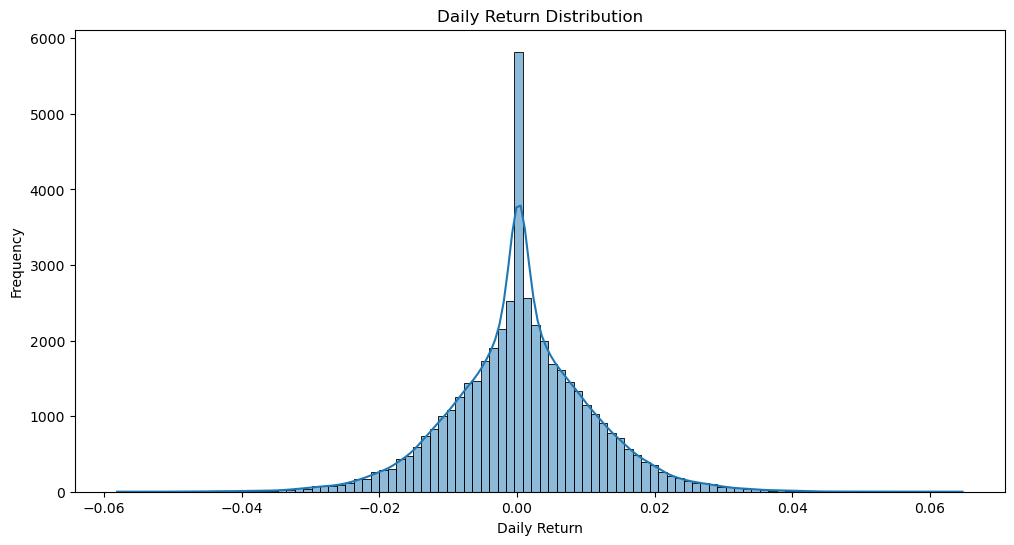

In [115]:
# =========================================================
# 5. DAILY RETURN DISTRIBUTION
# =========================================================
plt.figure(figsize=(12,6))
sns.histplot(
    nav['daily_return'].dropna(),
    bins=100,  kde=True
)

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [116]:
# =========================================================
# 6. CAGR FUNCTION
# =========================================================
def calculate_cagr(data, years):
    result = []
    for fund in data['amfi_code'].unique():
        temp = data[
            data['amfi_code'] == fund ]
        temp = temp.sort_values('date')
        end_date = temp['date'].max()
        start_date = end_date - pd.DateOffset(years=years)
        temp_period = temp[
            temp['date'] >= start_date
        ]

        if len(temp_period) < 2:
            continue
        nav_start = temp_period.iloc[0]['nav']
        nav_end = temp_period.iloc[-1]['nav']
        cagr = (
            (nav_end / nav_start)
            **
            (1 / years)
        ) - 1
        result.append([fund, cagr])
    return pd.DataFrame(
        result,
        columns=[
            'amfi_code',
            f'{years}Y_CAGR'
        ]

    )


In [117]:
# =========================================================
# 7. CALCULATE CAGR
# =========================================================
cagr_1y = calculate_cagr(nav, 1)
cagr_3y = calculate_cagr(nav, 3)
cagr_5y = calculate_cagr(nav, 5)
# ---------------------------------------------------------
cagr_table = (
    cagr_1y
    .merge(cagr_3y, on='amfi_code')
    .merge(cagr_5y, on='amfi_code')
)
print(cagr_table.head())


   amfi_code   1Y_CAGR   3Y_CAGR   5Y_CAGR
0     100016 -0.022243  0.012926  0.023168
1     100025  0.037050  0.039164  0.039127
2     100033  0.532324  0.324425  0.260741
3     101206  0.479241  0.289677  0.204427
4     101207 -0.239860 -0.041524  0.069533


In [118]:
# =========================================================
# 8. SHARPE RATIO
# =========================================================

RF = 0.065

sharpe_result = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    returns = temp['daily_return'].dropna()

    if len(returns) == 0:
        continue

    annual_return = (1 + returns.mean()) ** 252 - 1

    annual_std = returns.std() * np.sqrt(252)

    sharpe = (

        (annual_return - RF)

        /

        annual_std

    ) * np.sqrt(252)

    sharpe_result.append([fund, sharpe])


In [119]:
sharpe_df = pd.DataFrame(

    sharpe_result,

    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]

)

In [120]:
sharpe_df = sharpe_df.sort_values(

    'sharpe_ratio',
    ascending=False
)
print(sharpe_df.head())


    amfi_code  sharpe_ratio
34     148567     27.458985
30     120843     24.798929
36     148569     23.554086
25     120505     22.609145
19     119551     22.500132


In [121]:
# =========================================================
# 9. SORTINO RATIO
# =========================================================

sortino_result = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    returns = temp['daily_return'].dropna()

    downside_returns = returns[
        returns < 0
    ]

    if len(downside_returns) == 0:
        continue

    annual_return = returns.mean() * 252

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino = (

        (annual_return - RF)

        /

        downside_std

    ) * np.sqrt(252)

    sortino_result.append([fund, sortino])


In [122]:
sortino_df = pd.DataFrame(

    sortino_result,

    columns=[
        'amfi_code',
        'sortino_ratio'
    ]

)

print(sortino_df.head())

   amfi_code  sortino_ratio
0     100016      -5.572706
1     100025     -14.950949
2     100033      29.036601
3     101206      28.567175
4     101207       4.391584


In [123]:
# =========================================================
# 10. BENCHMARK RETURNS
# =========================================================

nifty100 = benchmark[

    benchmark['index_name'].str.contains(

        'NIFTY100',

        case=False,

        na=False

    )

].copy()


In [124]:

nifty100['benchmark_return'] = (

    nifty100['close_value']

    .pct_change()

)

In [125]:
# =========================================================
# 11. ALPHA & BETA
# =========================================================

alpha_beta_result = []

for fund in nav['amfi_code'].unique():

    fund_df = nav[

        nav['amfi_code'] == fund

    ][['date', 'daily_return']]

    merged = pd.merge(

        fund_df,

        nifty100[['date', 'benchmark_return']],

        on='date',

        how='inner'

    )

    merged = merged.dropna()

    if len(merged) < 10:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(

        merged['benchmark_return'],

        merged['daily_return']

    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_result.append([

        fund,

        alpha,

        beta

    ])

# ---------------------------------------------------------

alpha_beta_df = pd.DataFrame(

    alpha_beta_result,

    columns=[

        'amfi_code',

        'alpha',

        'beta'

    ]

)

print(alpha_beta_df.head())


   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [126]:

# ---------------------------------------------------------

alpha_beta_df.to_csv(

    "alpha_beta.csv",

    index=False

)

In [127]:
# =========================================================
# 12. MAXIMUM DRAWDOWN
# =========================================================

drawdown_result = []

for fund in nav['amfi_code'].unique():

    temp = nav[

        nav['amfi_code'] == fund

    ].copy()

    temp['running_max'] = (

        temp['nav']

        .cummax()

    )

    temp['drawdown'] = (

        temp['nav']

        /

        temp['running_max']

    ) - 1

    max_dd = temp['drawdown'].min()

    worst_row = temp.loc[
        temp['drawdown'].idxmin()
    ]

    drawdown_result.append([

        fund,

        max_dd,

        worst_row['date']

    ])

# ---------------------------------------------------------

drawdown_df = pd.DataFrame(

    drawdown_result,

    columns=[

        'amfi_code',

        'max_drawdown',

        'worst_drawdown_date'

    ]

)

print(drawdown_df.head())


   amfi_code  max_drawdown worst_drawdown_date
0     100016     -0.247344          2022-09-15
1     100025     -0.043083          2023-07-28
2     100033     -0.162172          2022-05-12
3     101206     -0.112916          2023-07-05
4     101207     -0.354469          2026-05-11


In [128]:
# =========================================================
# 13. CREATE SCORECARD
# =========================================================

scorecard = cagr_table.copy()

# ---------------------------------------------------------

scorecard = scorecard.merge(
    sharpe_df,
    on='amfi_code',
    how='left'
)

# ---------------------------------------------------------

scorecard = scorecard.merge(
    sortino_df,
    on='amfi_code',
    how='left'
)

# ---------------------------------------------------------

scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code',
    how='left'
)

# ---------------------------------------------------------

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code',
    how='left'
)

# ---------------------------------------------------------

scorecard = scorecard.merge(
    fund_master[
        ['amfi_code', 'expense_ratio_pct']
    ],
    on='amfi_code',
    how='left'
)

# ---------------------------------------------------------

print(scorecard.shape)

print(scorecard.head())

(40, 11)
   amfi_code   1Y_CAGR   3Y_CAGR   5Y_CAGR  sharpe_ratio  sortino_ratio  \
0     100016 -0.022243  0.012926  0.023168     -3.128968      -5.572706   
1     100025  0.037050  0.039164  0.039127     -8.625261     -14.950949   
2     100033  0.532324  0.324425  0.260741     20.751052      29.036601   
3     101206  0.479241  0.289677  0.204427     18.994060      28.567175   
4     101207 -0.239860 -0.041524  0.069533      2.945510       4.391584   

      alpha      beta  max_drawdown worst_drawdown_date  expense_ratio_pct  
0  0.037476 -0.058268     -0.247344          2022-09-15               1.55  
1  0.042818  0.001158     -0.043083          2023-07-28               0.56  
2  0.271954  0.005104     -0.162172          2022-05-12               1.38  
3  0.213998  0.021086     -0.112916          2023-07-05               1.60  
4  0.108971 -0.065289     -0.354469          2026-05-11               1.53  


In [129]:
nav['amfi_code'] = nav['amfi_code'].astype(str)

cagr_table['amfi_code'] = cagr_table['amfi_code'].astype(str)

sharpe_df['amfi_code'] = sharpe_df['amfi_code'].astype(str)

sortino_df['amfi_code'] = sortino_df['amfi_code'].astype(str)

alpha_beta_df['amfi_code'] = alpha_beta_df['amfi_code'].astype(str)

drawdown_df['amfi_code'] = drawdown_df['amfi_code'].astype(str)

fund_master['amfi_code'] = fund_master['amfi_code'].astype(str)

In [132]:
# =========================================================
# 15. RANKING
# =========================================================

scorecard['return_rank'] = (
    scorecard['3Y_CAGR']
    .rank(ascending=False)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)

scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=True)
)

In [133]:
# =========================================================
# 16. CREATE MISSING RANKS
# =========================================================

scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)

# ---------------------------------------------------------

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=True)
)

In [134]:
# =========================================================
# 17. FUND SCORE
# =========================================================

scorecard['fund_score'] = (

    0.30 * scorecard['return_rank']

    +

    0.25 * scorecard['sharpe_rank']

    +

    0.20 * scorecard['alpha_rank']

    +

    0.15 * scorecard['expense_rank']

    +

    0.10 * scorecard['drawdown_rank']

)


In [135]:
# =========================================================
# 18. NORMALIZE SCORE
# =========================================================
scorecard['fund_score'] = (
    100 *
    (
        scorecard['fund_score'].max()
        -
        scorecard['fund_score']
    )
    /
    (
        scorecard['fund_score'].max()
        -
        scorecard['fund_score'].min()
    )
)

In [136]:
# =========================================================
# 19. SORT SCORECARD
# =========================================================

scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)


In [137]:
# =========================================================
# 20. SAVE FILE
# =========================================================

scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [138]:
# =========================================================
# 21. CHECK OUTPUT
# =========================================================

print(scorecard.head())

print("fund_scorecard.csv CREATED SUCCESSFULLY")

    amfi_code   1Y_CAGR   3Y_CAGR   5Y_CAGR  sharpe_ratio  sortino_ratio  \
25     120505  0.296047  0.317775  0.283768     22.609145      32.214979   
16     119094  0.222611  0.351118  0.244453     18.822335      27.046947   
2      100033  0.532324  0.324425  0.260741     20.751052      29.036601   
34     148567  0.203607  0.340009  0.267993     27.458985      37.870930   
30     120843  0.266571  0.295828  0.267425     24.798929      37.532417   

       alpha      beta  max_drawdown worst_drawdown_date  expense_ratio_pct  \
25  0.292636  0.000549     -0.181885          2025-01-23               1.36   
16  0.260767 -0.066265     -0.209609          2022-08-11               1.38   
2   0.271954  0.005104     -0.162172          2022-05-12               1.38   
34  0.269838  0.023684     -0.112657          2023-10-20               1.46   
30  0.273305 -0.022830     -0.129740          2022-04-13               1.45   

    return_rank  sharpe_rank  alpha_rank  expense_rank  drawdown_ran

In [141]:
# =========================================================
# 17. TOP 5 FUNDS
# =========================================================

top5_funds = scorecard.head(5)['amfi_code']

print(top5_funds)

25    120505
16    119094
2     100033
34    148567
30    120843
Name: amfi_code, dtype: int64


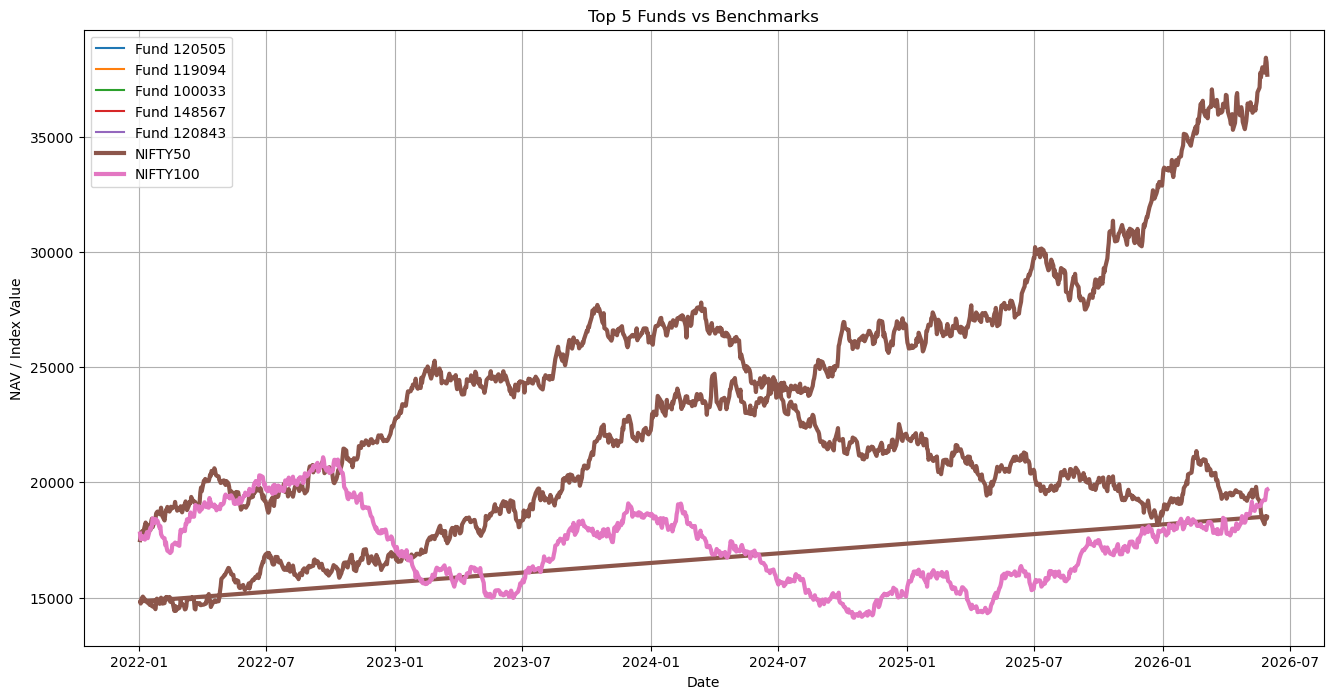

benchmark_comparison.png SAVED SUCCESSFULLY


In [144]:
# =========================================================
# 18. BENCHMARK COMPARISON CHART
# =========================================================

# NIFTY50 DATA

nifty50 = benchmark[
    benchmark['index_name']
    .str.upper()
    .str.contains('NIFTY50')
].copy()

# ---------------------------------------------------------

plt.figure(figsize=(16,8))

# ---------------------------------------------------------
# TOP 5 FUND NAV PLOTS
# ---------------------------------------------------------

for fund in top5_funds:

    temp = nav[
        nav['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=f"Fund {fund}"
    )

# ---------------------------------------------------------
# NIFTY50 PLOT
# ---------------------------------------------------------

plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    linewidth=3,
    label='NIFTY50'
)

# ---------------------------------------------------------
# NIFTY100 PLOT
# ---------------------------------------------------------

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    linewidth=3,
    label='NIFTY100'
)

# ---------------------------------------------------------

plt.title("Top 5 Funds vs Benchmarks")

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.legend()

plt.grid(True)

# ---------------------------------------------------------
# SAVE PNG
# ---------------------------------------------------------

plt.savefig(
    r"C:\Users\lenovo\OneDrive\Desktop\Data_Analyst_Intern\bluestock_mf_capstone\Data\Processed\benchmark_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("benchmark_comparison.png SAVED SUCCESSFULLY")